In [49]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import typing_extensions
import typing_extensions
print(typing_extensions.__file__)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from scipy.stats import ttest_ind

# Load the dataset
df_mat = pd.read_csv(('student-mat.csv'), sep=';')
df_por = pd.read_csv(('student-por.csv'), sep=';')

/opt/homebrew/Caskroom/miniforge/base/lib/python3.10/site-packages/typing_extensions.py


In [50]:
df_mat.head()
df_por.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [51]:
df_mat.info()
df_por.info()

df_mat.describe()
df_por.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


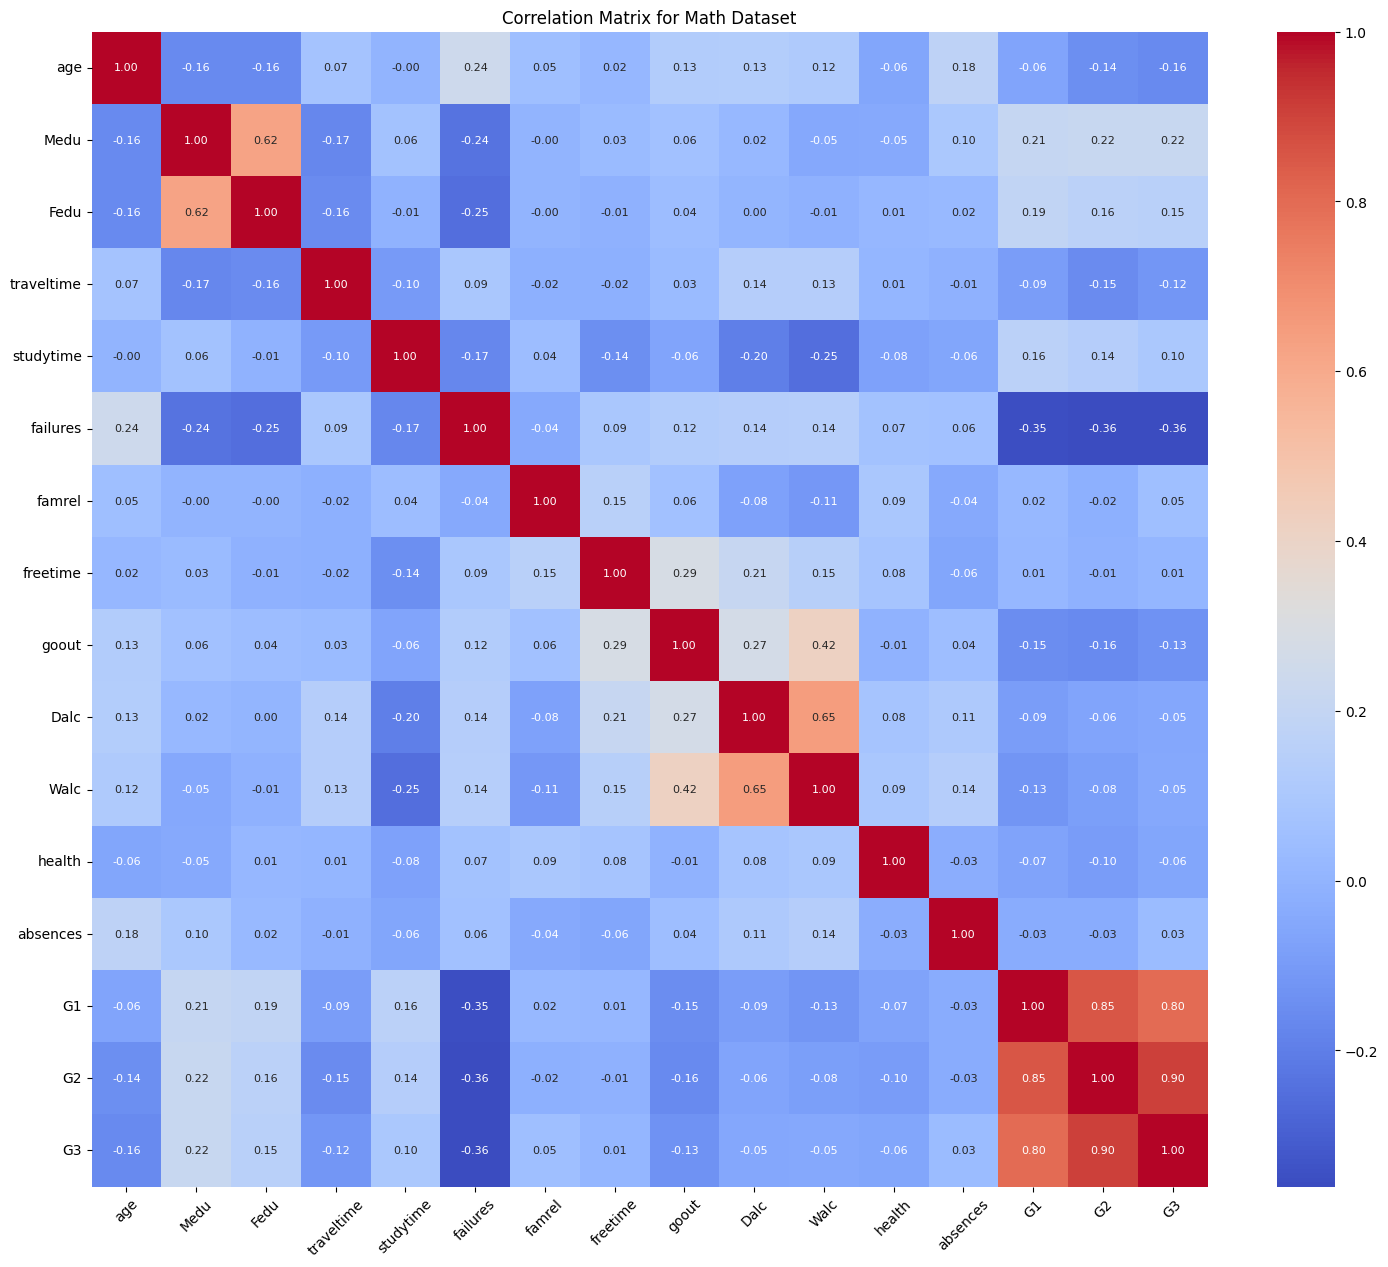

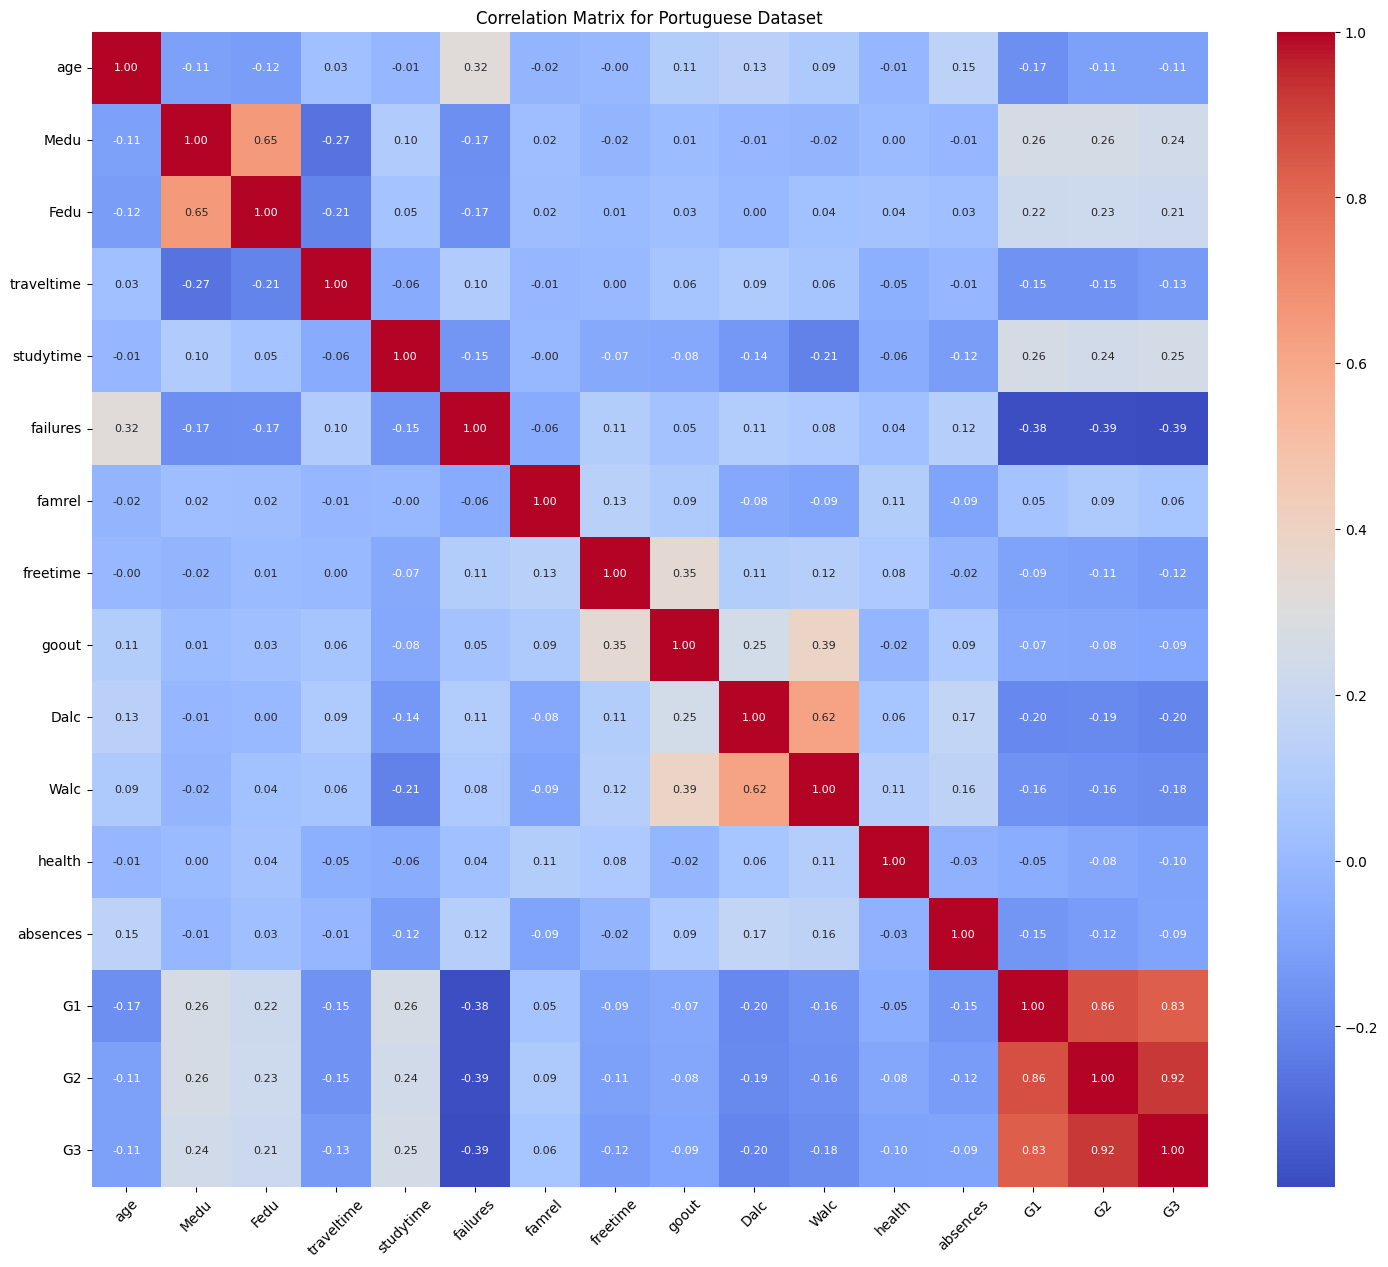

In [52]:
# Select only numeric columns for correlation matrix
numeric_cols_mat = df_mat.select_dtypes(include=[np.number])
numeric_cols_por = df_por.select_dtypes(include=[np.number])

# Correlation matrix for math dataset
correlation_mat = numeric_cols_mat.corr()
plt.figure(figsize=(18, 15))  
sns.heatmap(correlation_mat, annot=True, cmap='coolwarm', annot_kws={"size": 8}, fmt=".2f")  
plt.xticks(rotation=45)  
plt.yticks(rotation=0)  
plt.title('Correlation Matrix for Math Dataset')
plt.show()

# Correlation matrix for Portuguese dataset
correlation_por = numeric_cols_por.corr()
plt.figure(figsize=(18, 15))  
sns.heatmap(correlation_por, annot=True, cmap='coolwarm', annot_kws={"size": 8}, fmt=".2f")  
plt.xticks(rotation=45) 
plt.yticks(rotation=0)  
plt.title('Correlation Matrix for Portuguese Dataset')
plt.show()


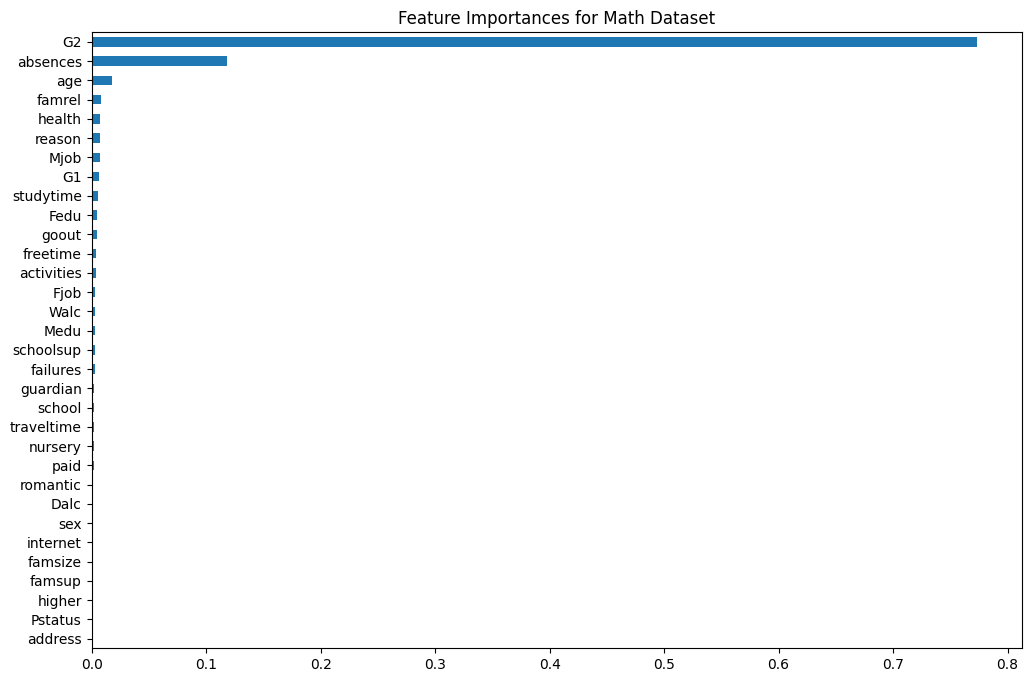

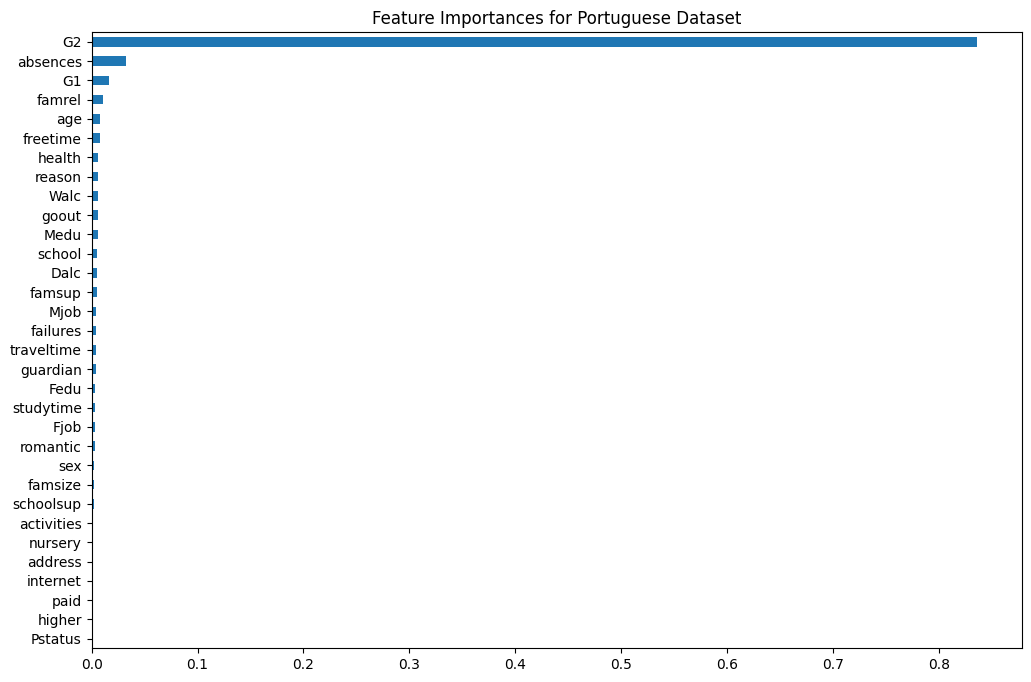

In [53]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

# Encoding categorical variables
label_encoders = {}
for column in df_mat.select_dtypes(include=['object']).columns:
    label_encoders[column] = LabelEncoder()
    df_mat[column] = label_encoders[column].fit_transform(df_mat[column])
    df_por[column] = label_encoders[column].fit_transform(df_por[column])

# features and target variable for math
X_mat = df_mat.drop(['G3'], axis=1)
y_mat = df_mat['G3']

# features and target variable for Portuguese
X_por = df_por.drop(['G3'], axis=1)
y_por = df_por['G3']

# Random Forest Regressor for math 
rf_mat = RandomForestRegressor(n_estimators=100, random_state=42)
rf_mat.fit(X_mat, y_mat)

# Random Forest Regressor for Portuguese 
rf_por = RandomForestRegressor(n_estimators=100, random_state=42)
rf_por.fit(X_por, y_por)

# feature importances
feature_importances_mat = pd.Series(rf_mat.feature_importances_, index=X_mat.columns)
feature_importances_por = pd.Series(rf_por.feature_importances_, index=X_por.columns)

# for math dataset
plt.figure(figsize=(12, 8))
feature_importances_mat.sort_values().plot(kind='barh')
plt.title('Feature Importances for Math Dataset')
plt.show()

# for Portuguese dataset
plt.figure(figsize=(12, 8))
feature_importances_por.sort_values().plot(kind='barh')
plt.title('Feature Importances for Portuguese Dataset')
plt.show()


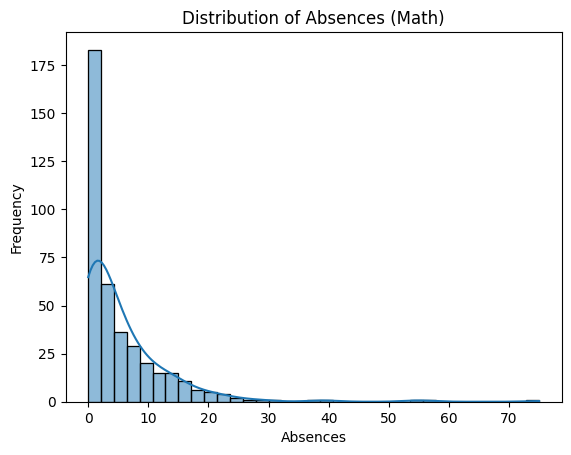

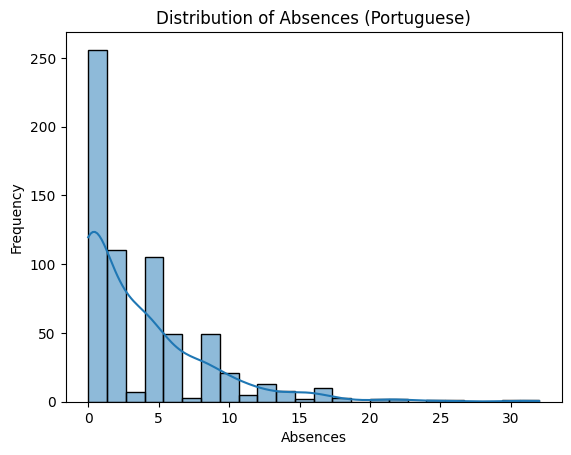

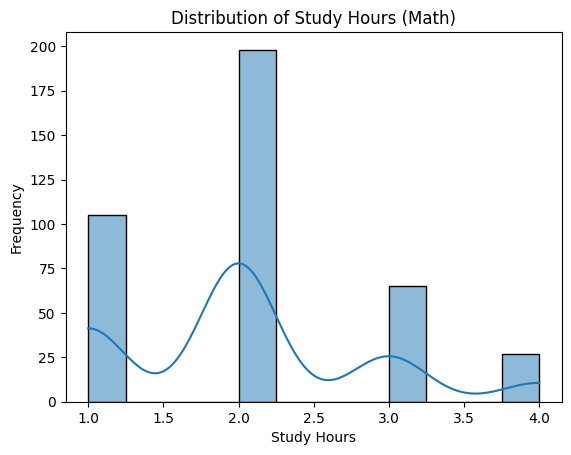

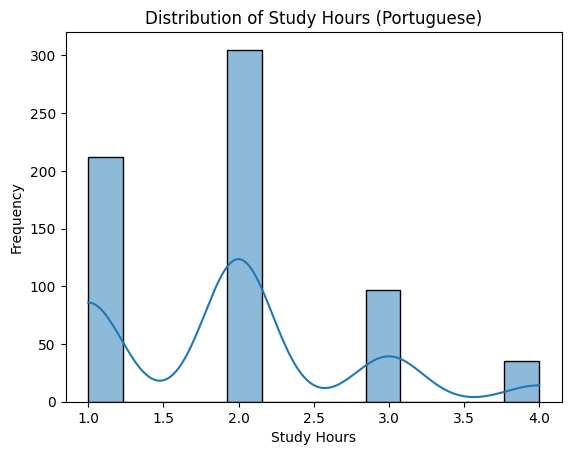

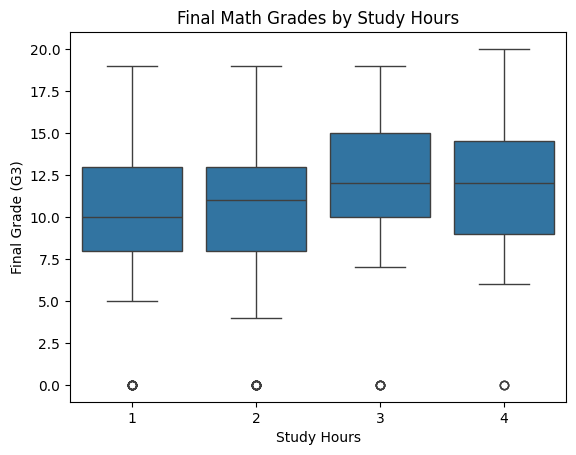

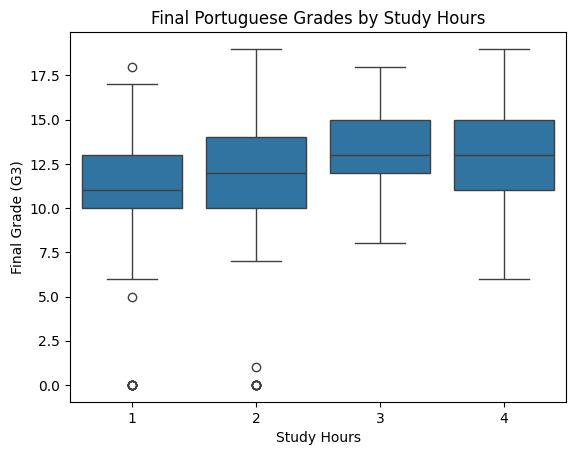

In [54]:
# Visualize key features
sns.histplot(df_mat['absences'], kde=True)
plt.title('Distribution of Absences (Math)')
plt.xlabel('Absences')
plt.ylabel('Frequency')
plt.show()

sns.histplot(df_por['absences'], kde=True)
plt.title('Distribution of Absences (Portuguese)')
plt.xlabel('Absences')
plt.ylabel('Frequency')
plt.show()

'''
sns.boxplot(x='absences', y='G3', data=df_mat)
plt.title('Final Math Grades by Absences')
plt.xlabel('Absences')
plt.ylabel('Final Grade (G3)')
plt.show()

sns.boxplot(x='absences', y='G3', data=df_por)
plt.title('Final Portuguese Grades by Absences')
plt.xlabel('Absences')
plt.ylabel('Final Grade (G3)')
plt.show()
'''

# Visualize key features
sns.histplot(df_mat['studytime'], kde=True)
plt.title('Distribution of Study Hours (Math)')
plt.xlabel('Study Hours')
plt.ylabel('Frequency')
plt.show()

sns.histplot(df_por['studytime'], kde=True)
plt.title('Distribution of Study Hours (Portuguese)')
plt.xlabel('Study Hours')
plt.ylabel('Frequency')
plt.show()

sns.boxplot(x='studytime', y='G3', data=df_mat)
plt.title('Final Math Grades by Study Hours')
plt.xlabel('Study Hours')
plt.ylabel('Final Grade (G3)')
plt.show()

sns.boxplot(x='studytime', y='G3', data=df_por)
plt.title('Final Portuguese Grades by Study Hours')
plt.xlabel('Study Hours')
plt.ylabel('Final Grade (G3)')
plt.show()


Based on the random forest for feature importance it showed that G2 and Absences have the most effect on grades. But when you look at the graph above for absences it is clear that absences is important becasue majority of the students missed 0 classes. So I think that causes it to be skewed and won't be using it. 

So I think study time would be a good hypotheis as from the preliminary graphs above on avg ppl who study more than 2 hrs have better final (G3) grades.

Hypothesis 1: Students who perform better in G2 have a better final grade
Hypothesis 2: The more a student studies the better their final grade 

#### Hypothesis Testing

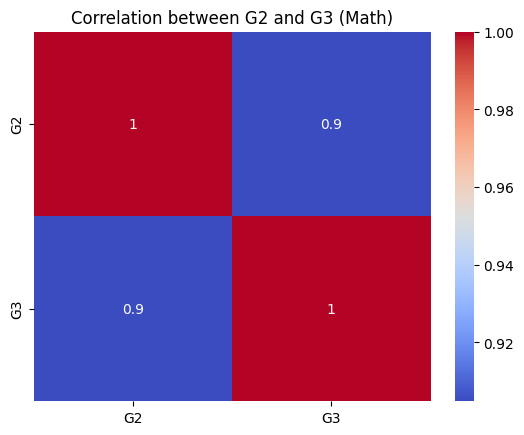

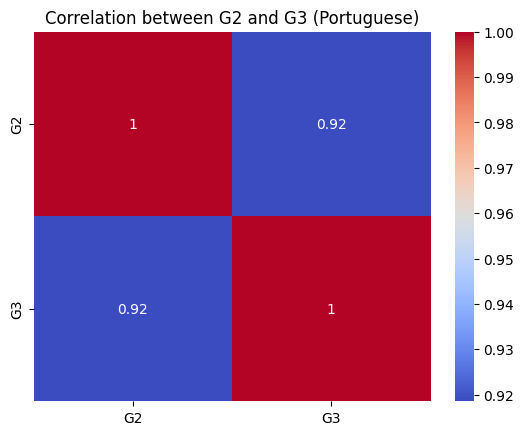

In [55]:
# Hypo 1 Correlation
correlation_grades_mat = df_mat[['G2', 'G3']].corr()
sns.heatmap(correlation_grades_mat, annot=True, cmap='coolwarm')
plt.title('Correlation between G2 and G3 (Math)')
plt.show()

correlation_grades_por = df_por[['G2', 'G3']].corr()
sns.heatmap(correlation_grades_por, annot=True, cmap='coolwarm')
plt.title('Correlation between G2 and G3 (Portuguese)')
plt.show()


Very strong correlation between G2 and G3 for both math and portugese scores.

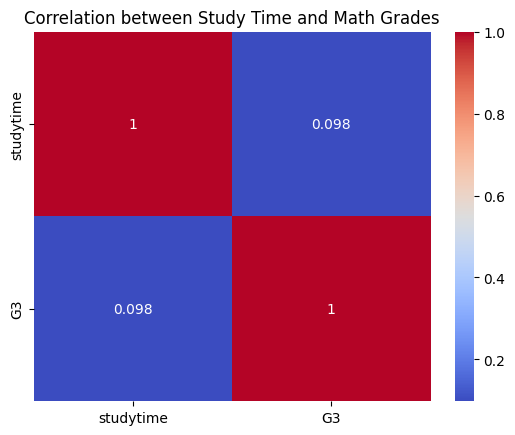

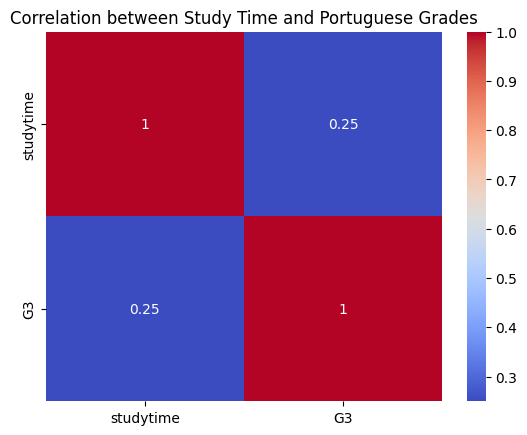

In [56]:
# Hypo 2 Correlation
correlation_studytime_mat = df_mat[['studytime', 'G3']].corr()
sns.heatmap(correlation_studytime_mat, annot=True, cmap='coolwarm')
plt.title('Correlation between Study Time and Math Grades')
plt.show()

correlation_studytime_por = df_por[['studytime', 'G3']].corr()
sns.heatmap(correlation_studytime_por, annot=True, cmap='coolwarm')
plt.title('Correlation between Study Time and Portuguese Grades')
plt.show()


Higher correlation between study time and portugese grades with very minor significance for math scores.

#### Significance Test

In [57]:
# Hypo 1
# Group students by performance in G2
high_G2_mat = df_mat[df_mat['G2'] > df_mat['G2'].mean()]['G3']
low_G2_mat = df_mat[df_mat['G2'] <= df_mat['G2'].mean()]['G3']

high_G2_por = df_por[df_por['G2'] > df_por['G2'].mean()]['G3']
low_G2_por = df_por[df_por['G2'] <= df_por['G2'].mean()]['G3']

# Perform t-tests
t_stat_mat_G2, p_val_mat_G2 = ttest_ind(high_G2_mat, low_G2_mat)
t_stat_por_G2, p_val_por_G2 = ttest_ind(high_G2_por, low_G2_por)

print(f'Math Grades - High G2 vs Low G2: T-statistic: {t_stat_mat_G2}, P-value: {p_val_mat_G2}')
print(f'Portuguese Grades - High G2 vs Low G2: T-statistic: {t_stat_por_G2}, P-value: {p_val_por_G2}')

Math Grades - High G2 vs Low G2: T-statistic: 21.262798435160786, P-value: 2.5083044050197263e-67
Portuguese Grades - High G2 vs Low G2: T-statistic: 26.743420041217135, P-value: 1.0842986029698614e-106


In [58]:
# Hypo 2
# Group students by study time
low_studytime_mat = df_mat[df_mat['studytime'] <= df_mat['studytime'].mean()]['G3']
high_studytime_mat = df_mat[df_mat['studytime'] > df_mat['studytime'].mean()]['G3']

low_studytime_por = df_por[df_por['studytime'] <= df_por['studytime'].mean()]['G3']
high_studytime_por = df_por[df_por['studytime'] > df_por['studytime'].mean()]['G3']

# Perform t-tests
t_stat_mat_studytime, p_val_mat_studytime = ttest_ind(low_studytime_mat, high_studytime_mat)
t_stat_por_studytime, p_val_por_studytime = ttest_ind(low_studytime_por, high_studytime_por)

print(f'Math Grades - Low vs High Study Time: T-statistic: {t_stat_mat_studytime}, P-value: {p_val_mat_studytime}')
print(f'Portuguese Grades - Low vs High Study Time: T-statistic: {t_stat_por_studytime}, P-value: {p_val_por_studytime}')


Math Grades - Low vs High Study Time: T-statistic: -2.2671657821810296, P-value: 0.023922647115463234
Portuguese Grades - Low vs High Study Time: T-statistic: -5.985723353508479, P-value: 3.5699095867948887e-09


#### Hypothesis 1: Students who perform better in G2 have a better final grade (G3)

1. Math Grades: The t-statistic of 21.26 and the extremely low p-value (2.51e-67) indicate a significant difference between students who performed well in G2 and those who did not. This strongly supports the hypothesis that better performance in G2 leads to better final grades in math.

2. Portuguese Grades: Similarly, the t-statistic of 26.74 and the very low p-value (1.08e-106) confirm a significant difference, supporting the hypothesis that better performance in G2 leads to better final grades in Portuguese.


#### Hypothesis 2: The more a student studies, the better their final grade (G3)

1. Math Grades: The t-statistic of -2.27 and the p-value (0.024) suggest a significant difference between students with low and high study times, supporting the hypothesis that more study time leads to better final grades in math.

2. Portuguese Grades: The t-statistic of -5.99 and the very low p-value (3.57e-09) indicate a significant difference, strongly supporting the hypothesis that more study time leads to better final grades in Portuguese.

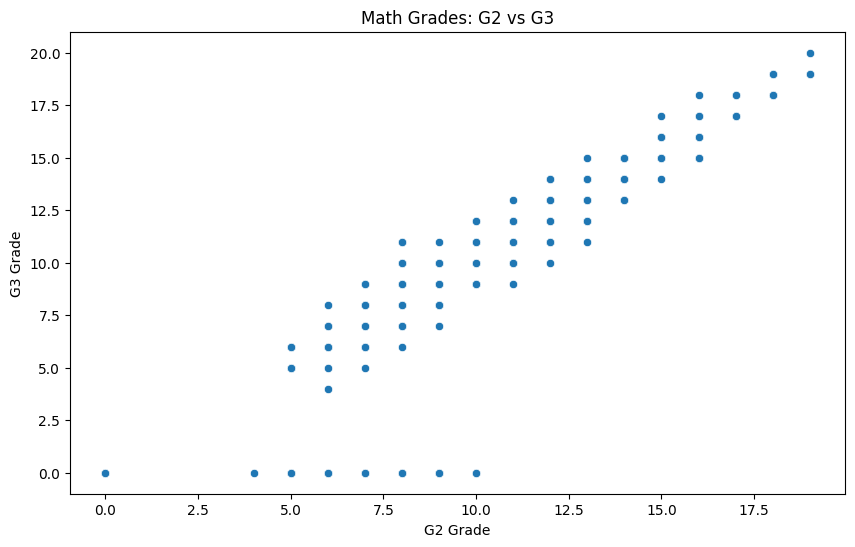

In [59]:
# Scatter plot for G2 vs G3 (Math)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='G2', y='G3', data=df_mat)
plt.title('Math Grades: G2 vs G3')
plt.xlabel('G2 Grade')
plt.ylabel('G3 Grade')
plt.show()


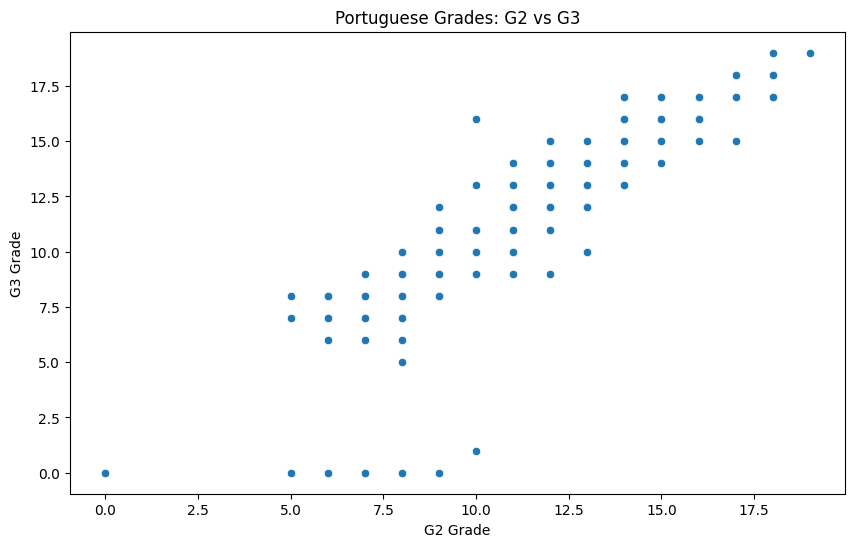

In [60]:
# Scatter plot for G2 vs G3 (Portuguese)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='G2', y='G3', data=df_por)
plt.title('Portuguese Grades: G2 vs G3')
plt.xlabel('G2 Grade')
plt.ylabel('G3 Grade')
plt.show()


As we can further see for the most part there is a linear trend between higher G2 grade to higher final grade.

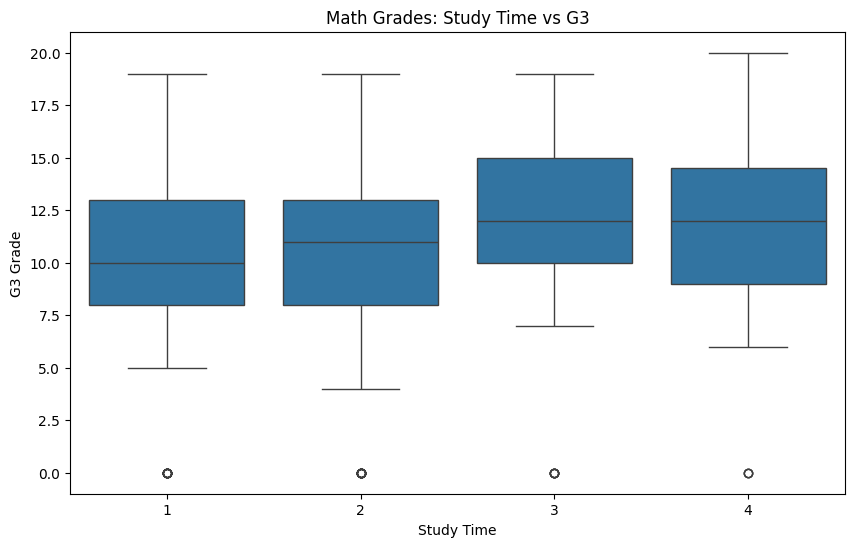

In [61]:
# Box plot for Study Time vs G3 (Math)
plt.figure(figsize=(10, 6))
sns.boxplot(x='studytime', y='G3', data=df_mat)
plt.title('Math Grades: Study Time vs G3')
plt.xlabel('Study Time')
plt.ylabel('G3 Grade')
plt.show()

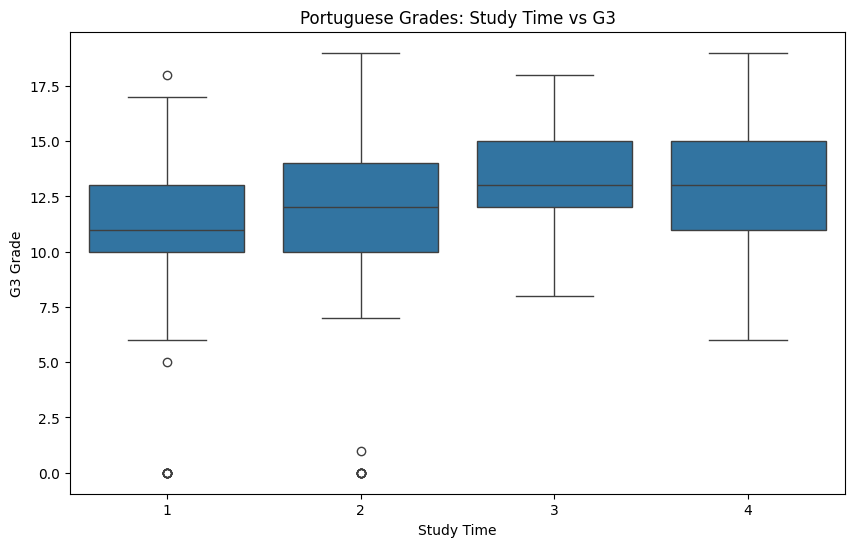

In [62]:
# Box plot for Study Time vs G3 (Portuguese)
plt.figure(figsize=(10, 6))
sns.boxplot(x='studytime', y='G3', data=df_por)
plt.title('Portuguese Grades: Study Time vs G3')
plt.xlabel('Study Time')
plt.ylabel('G3 Grade')
plt.show()

And as I showed the same visual above it is pretty clear for the most part the more you study the more likely you are to do better than those who studied less on average. 

So overall my testing supported both of my hypothesis. If I was to dive deeper I would maybe play around with the feature importance where I did random forest and do hyperparamter tuning or have better fine tuning, but I'm not sure if that would help as I'm not prediciting final grade rather just doing EDA and hypotheis testing. 

I could also dive deeper into data as I feel like the correlation between G2 and G3 is very high as it makes sense that those who do good in G2 will do really good in G3 as well, but I still kept it as maybe some who did good in G2 and G3 didn't do well in G1. 

So theres a lot of trends and other things I can try to find if I was to improve this analysis. 